In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install rasterio tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 67.8 MB/s eta 0:00:00


In [4]:
import os
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress tracking

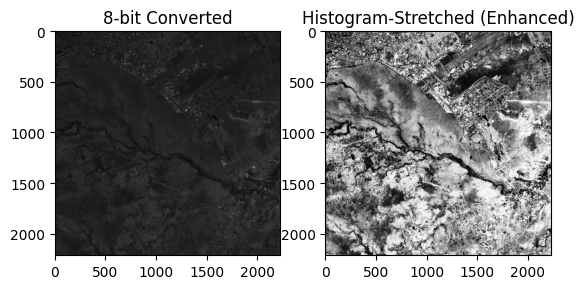

In [12]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Open the downloaded raw Sentinel-2 image
input_file = "/content/drive/MyDrive/NDVI Test Data/Sentinel2_Raw_2023-01-28.tif"  # Change to your filename
output_file = "Sentinel2_Processed_8bit.tif"

with rasterio.open(input_file) as src:
    img = src.read(1).astype(np.float32)  # Read first band (B4 or B8)

    # Apply reflectance scaling (0–10000 → 0–1)
    img = img / 10000.0
    img[img > 1] = 1  # Clip values above 1

    # Convert to 8-bit (0–255)
    img_8bit = (img * 255).astype(np.uint8)

    # Apply histogram stretching (contrast enhancement)
    img_equalized = cv2.equalizeHist(img_8bit)

    # Save the 8-bit processed image
    profile = src.profile
    profile.update(dtype=rasterio.uint8)

    with rasterio.open(output_file, "w", **profile) as dst:
        dst.write(img_equalized, 1)

# Show original vs processed image
plt.subplot(1, 2, 1)
plt.imshow(img_8bit, cmap="gray")
plt.title("8-bit Converted")

plt.subplot(1, 2, 2)
plt.imshow(img_equalized, cmap="gray")
plt.title("Histogram-Stretched (Enhanced)")

plt.show()
